## EVALUACIÓN MODELOS CON MEJOR RENDIMIENTO - ORDINALENCODER

### IMPORTAR LIBRERIAS

In [2]:
# utilidades 
import pandas as pd
import numpy as np

#utilidades modelos
import pickle
from joblib import dump, load

#reducción de dimensionalidad
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#graficos
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import plot_tree
import graphviz

# modelos 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
import xgboost
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.linear_model import LogisticRegression

#metricas
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import auc, accuracy_score, confusion_matrix, mean_squared_error, classification_report, precision_score

#interpretabilidad modelos
import shap

### CARGA DEL CONJUNTO DE DATOS - ONEHOTENCODER

In [3]:
df = pd.read_csv('../DATA/dataset-v1OrdinalEncoder.csv')
df

,Class,VJ.length.heavy,V.length.heavy,CDR1.length.aa.heavy,CDR2.length.aa.heavy,CDR3.length.aa.heavy,N1.length.heavy,N2.length.heavy,P3V.length.heavy,P5D.length.heavy,...,cdr3.cad.V.heavy.26,cdr3.cad.V.heavy.27,cdr3.cad.V.heavy.28,cdr3.cad.V.heavy.29,cdr3.cad.V.heavy.30,cdr3.cad.V.heavy.31,V.GENE.heavy,J.GENE.heavy,D.GENE.heavy,VJ.GENE.heavy
0,Neutralizing,347.0,285.0,8.0,7.0,14,0.0,14.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,1,1,1,1
1,Neutralizing,350.0,288.0,8.0,8.0,25,1.0,4.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,2,1,2,2
2,Neutralizing,333.0,285.0,8.0,7.0,15,6.0,2.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,1,2,3,3
3,Neutralizing,343.0,285.0,8.0,7.0,13,2.0,1.0,1.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,3,1,4,4
4,Neutralizing,332.0,285.0,8.0,7.0,13,0.0,2.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,3,2,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5932,Neutralizing,350.0,288.0,8.0,8.0,17,3.0,5.0,2.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,7,1,21,146
5933,Neutralizing,335.0,285.0,8.0,7.0,16,0.0,13.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,35,4,11,60
5934,Neutralizing,350.0,288.0,8.0,8.0,27,16.0,10.0,0.0,0.0,...,-0.184,0.0,0.0,0.0,0.0,0.0,28,1,16,121
5935,Neutralizing,337.0,288.0,8.0,8.0,18,4.0,4.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,23,3,14,37


### DISTRIBUCIÓN DE LOS CASOS DE ESTUDIO

In [4]:
print("Datos - Agrupados por: ", df.groupby('Class').size())

Datos - Agrupados por:  Class
Healthy            5092
Neutralizing        831
No Neutralizing      14
dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5937 entries, 0 to 5936
Columns: 322 entries, Class to VJ.GENE.heavy
dtypes: float64(316), int64(5), object(1)
memory usage: 14.6+ MB


### PCA - SELECCION DE CARACTERISTICAS CDR1, CDR2 Y CDR3

In [6]:
featuresCDR1 = ['cdr1.cad.I.heavy.0', 'cdr1.cad.I.heavy.1', 'cdr1.cad.I.heavy.2', 
                'cdr1.cad.I.heavy.3', 'cdr1.cad.I.heavy.4', 'cdr1.cad.I.heavy.5', 
                'cdr1.cad.I.heavy.6', 'cdr1.cad.I.heavy.7', 'cdr1.cad.I.heavy.8', 
                'cdr1.cad.I.heavy.9', 'cdr1.cad.I.heavy.10', 'cdr1.cad.I.heavy.11', 
                
                'cdr1.cad.II.heavy.0', 'cdr1.cad.II.heavy.1', 'cdr1.cad.II.heavy.2',
                'cdr1.cad.II.heavy.3', 'cdr1.cad.II.heavy.4', 'cdr1.cad.II.heavy.5',
                'cdr1.cad.II.heavy.6', 'cdr1.cad.II.heavy.7', 'cdr1.cad.II.heavy.8',
                'cdr1.cad.II.heavy.9', 'cdr1.cad.II.heavy.10', 'cdr1.cad.II.heavy.11',
                
                'cdr1.cad.III.heavy.0', 'cdr1.cad.III.heavy.1', 'cdr1.cad.III.heavy.2',
                'cdr1.cad.III.heavy.3', 'cdr1.cad.III.heavy.4', 'cdr1.cad.III.heavy.5',
                'cdr1.cad.III.heavy.6', 'cdr1.cad.III.heavy.7', 'cdr1.cad.III.heavy.8',
                'cdr1.cad.III.heavy.9', 'cdr1.cad.III.heavy.10', 'cdr1.cad.III.heavy.11',
                
                'cdr1.cad.IV.heavy.0', 'cdr1.cad.IV.heavy.1', 'cdr1.cad.IV.heavy.2',
                'cdr1.cad.IV.heavy.3', 'cdr1.cad.IV.heavy.4', 'cdr1.cad.IV.heavy.5',
                'cdr1.cad.IV.heavy.6', 'cdr1.cad.IV.heavy.7', 'cdr1.cad.IV.heavy.8',
                'cdr1.cad.IV.heavy.9', 'cdr1.cad.IV.heavy.10', 'cdr1.cad.IV.heavy.11',
                
                'cdr1.cad.V.heavy.0', 'cdr1.cad.V.heavy.1', 'cdr1.cad.V.heavy.2',
                'cdr1.cad.V.heavy.3', 'cdr1.cad.V.heavy.4', 'cdr1.cad.V.heavy.5',
                'cdr1.cad.V.heavy.6', 'cdr1.cad.V.heavy.7', 'cdr1.cad.V.heavy.8',
                'cdr1.cad.V.heavy.9', 'cdr1.cad.V.heavy.10', 'cdr1.cad.V.heavy.11',]

In [7]:
featuresCDR2 = ['cdr2.cad.I.heavy.0', 'cdr2.cad.I.heavy.1', 'cdr2.cad.I.heavy.2', 
                'cdr2.cad.I.heavy.3', 'cdr2.cad.I.heavy.4', 'cdr2.cad.I.heavy.5', 
                'cdr2.cad.I.heavy.6', 'cdr2.cad.I.heavy.7', 'cdr2.cad.I.heavy.8', 'cdr2.cad.I.heavy.9',
                
                'cdr2.cad.II.heavy.0', 'cdr2.cad.II.heavy.1', 'cdr2.cad.II.heavy.2',
                'cdr2.cad.II.heavy.3', 'cdr2.cad.II.heavy.4', 'cdr2.cad.II.heavy.5',
                'cdr2.cad.II.heavy.6', 'cdr2.cad.II.heavy.7', 'cdr2.cad.II.heavy.8', 'cdr2.cad.II.heavy.9',
                
                'cdr2.cad.III.heavy.0', 'cdr2.cad.III.heavy.1', 'cdr2.cad.III.heavy.2',
                'cdr2.cad.III.heavy.3', 'cdr2.cad.III.heavy.4', 'cdr2.cad.III.heavy.5',
                'cdr2.cad.III.heavy.6', 'cdr2.cad.III.heavy.7', 'cdr2.cad.III.heavy.8', 'cdr2.cad.III.heavy.9',
                
                'cdr2.cad.IV.heavy.0', 'cdr2.cad.IV.heavy.1', 'cdr2.cad.IV.heavy.2',
                'cdr2.cad.IV.heavy.3', 'cdr2.cad.IV.heavy.4', 'cdr2.cad.IV.heavy.5',
                'cdr2.cad.IV.heavy.6', 'cdr2.cad.IV.heavy.7', 'cdr2.cad.IV.heavy.8', 'cdr2.cad.IV.heavy.9',
                
                'cdr2.cad.V.heavy.0', 'cdr2.cad.V.heavy.1', 'cdr2.cad.V.heavy.2',
                'cdr2.cad.V.heavy.3', 'cdr2.cad.V.heavy.4', 'cdr2.cad.V.heavy.5', 
                'cdr2.cad.V.heavy.6', 'cdr2.cad.V.heavy.7', 'cdr2.cad.V.heavy.8', 'cdr2.cad.V.heavy.9',]

In [8]:
featuresCDR3 = ['cdr3.cad.I.heavy.0', 'cdr3.cad.I.heavy.1', 'cdr3.cad.I.heavy.2', 'cdr3.cad.I.heavy.3',
                'cdr3.cad.I.heavy.4', 'cdr3.cad.I.heavy.5', 'cdr3.cad.I.heavy.6', 'cdr3.cad.I.heavy.7',
                'cdr3.cad.I.heavy.8', 'cdr3.cad.I.heavy.9', 'cdr3.cad.I.heavy.10', 'cdr3.cad.I.heavy.11',
                'cdr3.cad.I.heavy.12', 'cdr3.cad.I.heavy.13', 'cdr3.cad.I.heavy.14', 'cdr3.cad.I.heavy.15',
                'cdr3.cad.I.heavy.16', 'cdr3.cad.I.heavy.17', 'cdr3.cad.I.heavy.18', 'cdr3.cad.I.heavy.19',
                'cdr3.cad.I.heavy.20', 'cdr3.cad.I.heavy.21', 'cdr3.cad.I.heavy.22', 'cdr3.cad.I.heavy.23',
                'cdr3.cad.I.heavy.24', 'cdr3.cad.I.heavy.25', 'cdr3.cad.I.heavy.26', 'cdr3.cad.I.heavy.27',
                'cdr3.cad.I.heavy.28', 'cdr3.cad.I.heavy.29', 'cdr3.cad.I.heavy.30', 'cdr3.cad.I.heavy.31',

                'cdr3.cad.II.heavy.0', 'cdr3.cad.II.heavy.1', 'cdr3.cad.II.heavy.2', 'cdr3.cad.II.heavy.3',
                'cdr3.cad.II.heavy.4', 'cdr3.cad.II.heavy.5', 'cdr3.cad.II.heavy.6', 'cdr3.cad.II.heavy.7',
                'cdr3.cad.II.heavy.8', 'cdr3.cad.II.heavy.9', 'cdr3.cad.II.heavy.10', 'cdr3.cad.II.heavy.11',
                'cdr3.cad.II.heavy.12', 'cdr3.cad.II.heavy.13', 'cdr3.cad.II.heavy.14', 'cdr3.cad.II.heavy.15',
                'cdr3.cad.II.heavy.16', 'cdr3.cad.II.heavy.17', 'cdr3.cad.II.heavy.18', 'cdr3.cad.II.heavy.19',
                'cdr3.cad.II.heavy.20', 'cdr3.cad.II.heavy.21', 'cdr3.cad.II.heavy.22', 'cdr3.cad.II.heavy.23',
                'cdr3.cad.II.heavy.24', 'cdr3.cad.II.heavy.25', 'cdr3.cad.II.heavy.26', 'cdr3.cad.II.heavy.27',
                'cdr3.cad.II.heavy.28', 'cdr3.cad.II.heavy.29', 'cdr3.cad.II.heavy.30', 'cdr3.cad.II.heavy.31',

                'cdr3.cad.III.heavy.0', 'cdr3.cad.III.heavy.1', 'cdr3.cad.III.heavy.2', 'cdr3.cad.III.heavy.3',
                'cdr3.cad.III.heavy.4', 'cdr3.cad.III.heavy.5', 'cdr3.cad.III.heavy.6', 'cdr3.cad.III.heavy.7',
                'cdr3.cad.III.heavy.8', 'cdr3.cad.III.heavy.9', 'cdr3.cad.III.heavy.10', 'cdr3.cad.III.heavy.11',
                'cdr3.cad.III.heavy.12', 'cdr3.cad.III.heavy.13', 'cdr3.cad.III.heavy.14', 'cdr3.cad.III.heavy.15',
                'cdr3.cad.III.heavy.16', 'cdr3.cad.III.heavy.17', 'cdr3.cad.III.heavy.18', 'cdr3.cad.III.heavy.19',
                'cdr3.cad.III.heavy.20', 'cdr3.cad.III.heavy.21', 'cdr3.cad.III.heavy.22', 'cdr3.cad.III.heavy.23',
                'cdr3.cad.III.heavy.24', 'cdr3.cad.III.heavy.25', 'cdr3.cad.III.heavy.26', 'cdr3.cad.III.heavy.27',
                'cdr3.cad.III.heavy.28', 'cdr3.cad.III.heavy.29', 'cdr3.cad.III.heavy.30', 'cdr3.cad.III.heavy.31',

                'cdr3.cad.IV.heavy.0', 'cdr3.cad.IV.heavy.1', 'cdr3.cad.IV.heavy.2', 'cdr3.cad.IV.heavy.3',
                'cdr3.cad.IV.heavy.4', 'cdr3.cad.IV.heavy.5', 'cdr3.cad.IV.heavy.6', 'cdr3.cad.IV.heavy.7',
                'cdr3.cad.IV.heavy.8', 'cdr3.cad.IV.heavy.9', 'cdr3.cad.IV.heavy.10', 'cdr3.cad.IV.heavy.11',
                'cdr3.cad.IV.heavy.12', 'cdr3.cad.IV.heavy.13', 'cdr3.cad.IV.heavy.14', 'cdr3.cad.IV.heavy.15',
                'cdr3.cad.IV.heavy.16', 'cdr3.cad.IV.heavy.17', 'cdr3.cad.IV.heavy.18', 'cdr3.cad.IV.heavy.19',
                'cdr3.cad.IV.heavy.20', 'cdr3.cad.IV.heavy.21', 'cdr3.cad.IV.heavy.22', 'cdr3.cad.IV.heavy.23',
                'cdr3.cad.IV.heavy.24', 'cdr3.cad.IV.heavy.25', 'cdr3.cad.IV.heavy.26', 'cdr3.cad.IV.heavy.27',
                'cdr3.cad.IV.heavy.28', 'cdr3.cad.IV.heavy.29', 'cdr3.cad.IV.heavy.30', 'cdr3.cad.IV.heavy.31',

                'cdr3.cad.V.heavy.0', 'cdr3.cad.V.heavy.1', 'cdr3.cad.V.heavy.2', 'cdr3.cad.V.heavy.3',
                'cdr3.cad.V.heavy.4', 'cdr3.cad.V.heavy.5', 'cdr3.cad.V.heavy.6', 'cdr3.cad.V.heavy.7',
                'cdr3.cad.V.heavy.8', 'cdr3.cad.V.heavy.9', 'cdr3.cad.V.heavy.10', 'cdr3.cad.V.heavy.11',
                'cdr3.cad.V.heavy.12', 'cdr3.cad.V.heavy.13', 'cdr3.cad.V.heavy.14', 'cdr3.cad.V.heavy.15',
                'cdr3.cad.V.heavy.16', 'cdr3.cad.V.heavy.17', 'cdr3.cad.V.heavy.18', 'cdr3.cad.V.heavy.19',
                'cdr3.cad.V.heavy.20', 'cdr3.cad.V.heavy.21', 'cdr3.cad.V.heavy.22', 'cdr3.cad.V.heavy.23', 
                'cdr3.cad.V.heavy.24', 'cdr3.cad.V.heavy.25', 'cdr3.cad.V.heavy.26', 'cdr3.cad.V.heavy.27',
                'cdr3.cad.V.heavy.28', 'cdr3.cad.V.heavy.29', 'cdr3.cad.V.heavy.30', 'cdr3.cad.V.heavy.31',]

### PCA - SEPARAR CARACTERISTICAS CDR1, CDR2 Y CDR3

In [9]:
# Separating out the features
xCDR1 = df.loc[:, featuresCDR1].values
# Separating out the features
xCDR2 = df.loc[:, featuresCDR2].values
# Separating out the features
xCDR3 = df.loc[:, featuresCDR3].values
# Separating out the target
y = df.loc[:,['Class']].values

### PCA - STANDARIZAR CARACTERISTICAS CDR1, CDR2 Y CDR3

In [10]:
# Standardizing the features
xCDR1 = StandardScaler().fit_transform(xCDR1)
xCDR2 = StandardScaler().fit_transform(xCDR2)
xCDR3 = StandardScaler().fit_transform(xCDR3)

### PCA - TRANSFORMACION DE DATOS CDR1, CDR2 Y CDR3

In [11]:
pcaCDR1 = PCA(n_components=60)
principalComponentsCDR1 = pcaCDR1.fit_transform(xCDR1)
principalCDR1 = pd.DataFrame(data = principalComponentsCDR1
             , columns = ['CDR1-pc1', 'CDR1-pc2', 'CDR1-pc3', 'CDR1-pc4', 'CDR1-pc5',
                          'CDR1-pc6', 'CDR1-pc7', 'CDR1-pc8', 'CDR1-pc9', 'CDR1-pc10',
                          'CDR1-pc11', 'CDR1-pc12', 'CDR1-pc13', 'CDR1-pc14', 'CDR1-pc15',
                          'CDR1-pc16', 'CDR1-pc17', 'CDR1-pc18', 'CDR1-pc19', 'CDR1-pc20',
                          'CDR1-pc21', 'CDR1-pc22', 'CDR1-pc23', 'CDR1-pc24', 'CDR1-pc25',
                          'CDR1-pc26', 'CDR1-pc27', 'CDR1-pc28', 'CDR1-pc29', 'CDR1-pc30',
                          'CDR1-pc31', 'CDR1-pc32', 'CDR1-pc33', 'CDR1-pc34', 'CDR1-pc35',
                          'CDR1-pc36', 'CDR1-pc37', 'CDR1-pc38', 'CDR1-pc39', 'CDR1-pc40',
                          'CDR1-pc41', 'CDR1-pc42', 'CDR1-pc43', 'CDR1-pc44', 'CDR1-pc45',
                          'CDR1-pc46', 'CDR1-pc47', 'CDR1-pc48', 'CDR1-pc49', 'CDR1-pc50',
                          'CDR1-pc51', 'CDR1-pc52', 'CDR1-pc53', 'CDR1-pc54', 'CDR1-pc55',
                          'CDR1-pc56', 'CDR1-pc57', 'CDR1-pc58', 'CDR1-pc59', 'CDR1-pc60',
                         ])

principalCDR1

,CDR1-pc1,CDR1-pc2,CDR1-pc3,CDR1-pc4,CDR1-pc5,CDR1-pc6,CDR1-pc7,CDR1-pc8,CDR1-pc9,CDR1-pc10,...,CDR1-pc51,CDR1-pc52,CDR1-pc53,CDR1-pc54,CDR1-pc55,CDR1-pc56,CDR1-pc57,CDR1-pc58,CDR1-pc59,CDR1-pc60
0,0.267630,-0.562812,2.523779,0.876649,2.934043,-0.875602,0.390981,-2.124537,-2.932845,1.120679,...,-0.478347,-0.078390,1.176245e-13,1.209035e-14,-3.474586e-15,-1.683796e-15,2.064353e-16,-6.555943e-16,-2.685965e-15,-6.176288e-16
1,-0.337665,1.301852,-1.245905,0.151868,-1.225960,-2.565972,0.466240,-1.429170,-0.758618,-1.193200,...,0.001164,0.010047,8.674296e-16,-9.902211e-16,2.526435e-16,-5.117362e-16,1.062155e-15,-2.214614e-16,6.603004e-16,-1.071521e-16
2,-0.000438,0.058983,1.979043,1.398141,2.362591,-1.326044,0.377358,-1.794939,-3.218332,0.243879,...,0.039157,0.023668,2.141982e-14,7.498175e-15,1.421736e-14,-5.973228e-15,1.898411e-15,1.959460e-15,9.568188e-15,7.441586e-16
3,0.204282,-0.520909,2.463982,1.085188,2.987208,-0.736511,0.402259,-2.201576,-2.515369,1.391985,...,0.111780,0.028820,8.810415e-16,1.899868e-15,4.455830e-15,5.383500e-16,-2.000068e-15,-6.616595e-16,9.177406e-16,5.216197e-16
4,-0.000438,0.058983,1.979043,1.398141,2.362591,-1.326044,0.377358,-1.794939,-3.218332,0.243879,...,0.039157,0.023668,-1.281990e-15,-7.513556e-16,-1.736859e-15,6.517615e-16,-2.610319e-15,2.079860e-15,-1.215381e-15,1.556100e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5932,-0.320667,1.264701,-1.168609,0.077149,-1.370121,-3.085444,0.376844,-1.161113,-1.149848,-1.096334,...,-0.000135,0.022016,5.497489e-17,-3.633219e-17,-1.962021e-18,-3.560298e-17,-5.890705e-17,4.978718e-18,5.481748e-18,1.597674e-17
5933,-0.022412,0.368659,2.423742,1.194578,0.987682,-1.690853,0.076536,-0.102489,-2.095128,0.822424,...,-0.722276,0.001691,-1.841289e-16,-1.951409e-16,-1.794121e-17,7.964681e-18,3.987550e-18,3.148434e-17,4.051865e-17,-1.680008e-17
5934,-0.395404,1.573719,-0.610918,0.700559,1.604525,-0.201799,-0.020764,0.542749,-1.421127,0.854342,...,-0.032757,0.027890,3.197216e-17,4.021789e-18,-1.940992e-17,-1.409871e-17,-4.483607e-17,3.708467e-17,3.904510e-17,1.197168e-17
5935,-0.028928,-0.252382,-0.398731,0.745971,1.833160,1.805568,0.093986,-0.684071,0.552079,-3.124588,...,0.009881,0.008082,7.202484e-17,2.046704e-17,1.134540e-17,-2.274609e-17,-3.241241e-17,2.255231e-17,5.676773e-17,1.049645e-17


### PCA - RELACION DE VARIANZA CDR1

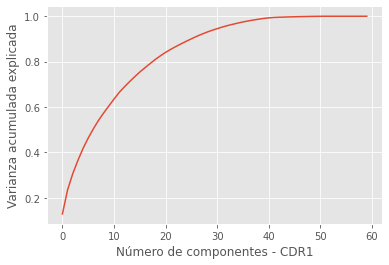

In [12]:
#graficamos el acumulado de varianza explicada en las nuevas dimensiones
plt.style.use('ggplot')
plt.plot(np.cumsum(pcaCDR1.explained_variance_ratio_))
plt.xlabel('Número de componentes - CDR1')
plt.ylabel('Varianza acumulada explicada')
plt.show()

In [13]:
print("shape of X_pca", principalCDR1.shape)
expl = pcaCDR1.explained_variance_ratio_
print(expl)
print('suma:',sum(expl[0:27]))

shape of X_pca (5937, 60)
[1.29012208e-01 1.05677191e-01 7.13551834e-02 5.87168210e-02
 5.28309172e-02 4.57014572e-02 4.05995603e-02 3.73808678e-02
 3.26695264e-02 3.08320307e-02 3.01897216e-02 2.92088386e-02
 2.43780388e-02 2.28728426e-02 2.17351682e-02 2.10870945e-02
 1.87984766e-02 1.83890507e-02 1.81092015e-02 1.61224677e-02
 1.51391206e-02 1.33778402e-02 1.25933200e-02 1.15008358e-02
 1.13593095e-02 1.08289996e-02 1.06480499e-02 9.66370379e-03
 9.12431501e-03 8.08337459e-03 7.30085325e-03 7.08322781e-03
 6.51122299e-03 5.55684010e-03 5.40988868e-03 5.00982917e-03
 4.36593798e-03 4.07424135e-03 3.54984826e-03 3.47927187e-03
 2.59803738e-03 1.71923061e-03 9.71883545e-04 7.65049643e-04
 7.15469741e-04 5.94111351e-04 5.57991750e-04 4.75329638e-04
 4.14093771e-04 3.79379733e-04 3.40581203e-04 1.42147765e-04
 4.44069463e-32 9.32248865e-33 8.03270047e-33 1.07385545e-33
 5.93883149e-34 5.93883149e-34 5.93883149e-34 1.23092045e-34]
suma: 0.911114139018481


In [14]:
pcaCDR2 = PCA(n_components=50)
principalComponentsCDR2 = pcaCDR2.fit_transform(xCDR2)
principalCDR2 = pd.DataFrame(data = principalComponentsCDR2
             , columns = ['CDR2-pc1', 'CDR2-pc2', 'CDR2-pc3', 'CDR2-pc4', 'CDR2-pc5',
                          'CDR2-pc6', 'CDR2-pc7', 'CDR2-pc8', 'CDR2-pc9', 'CDR2-pc10',
                          'CDR2-pc11', 'CDR2-pc12', 'CDR2-pc13', 'CDR2-pc14', 'CDR2-pc15',
                          'CDR2-pc16', 'CDR2-pc17', 'CDR2-pc18', 'CDR2-pc19', 'CDR2-pc20',
                          'CDR2-pc21', 'CDR2-pc22', 'CDR2-pc23', 'CDR2-pc24', 'CDR2-pc25',
                          'CDR2-pc26', 'CDR2-pc27', 'CDR2-pc28', 'CDR2-pc29', 'CDR2-pc30',
                          'CDR2-pc31', 'CDR2-pc32', 'CDR2-pc33', 'CDR2-pc34', 'CDR2-pc35',
                          'CDR2-pc36', 'CDR2-pc37', 'CDR2-pc38', 'CDR2-pc39', 'CDR2-pc40',
                          'CDR2-pc41', 'CDR2-pc42', 'CDR2-pc43', 'CDR2-pc44', 'CDR2-pc45',
                          'CDR2-pc46', 'CDR2-pc47', 'CDR2-pc48', 'CDR2-pc49', 'CDR2-pc50',
                         ])

principalCDR2

,CDR2-pc1,CDR2-pc2,CDR2-pc3,CDR2-pc4,CDR2-pc5,CDR2-pc6,CDR2-pc7,CDR2-pc8,CDR2-pc9,CDR2-pc10,...,CDR2-pc41,CDR2-pc42,CDR2-pc43,CDR2-pc44,CDR2-pc45,CDR2-pc46,CDR2-pc47,CDR2-pc48,CDR2-pc49,CDR2-pc50
0,0.007060,0.392423,2.646802,-0.402483,-2.011358,0.457950,1.935754,1.028513,-0.459984,-0.913140,...,0.011894,0.048476,-0.075570,0.020406,0.044098,-0.003237,0.043641,-0.052459,0.042821,0.016897
1,-0.514523,-2.841129,-2.257064,0.143036,1.010656,-1.207449,-1.085112,0.399848,-0.174304,-0.220060,...,-0.009904,-0.068164,-0.053227,-0.000465,-0.029356,0.113415,0.032848,0.023668,-0.007269,0.024066
2,0.007060,0.392423,2.646802,-0.402483,-2.011358,0.457950,1.935754,1.028513,-0.459984,-0.913140,...,0.011894,0.048476,-0.075570,0.020406,0.044098,-0.003237,0.043641,-0.052459,0.042821,0.016897
3,0.007060,0.392423,2.646802,-0.402483,-2.011358,0.457950,1.935754,1.028513,-0.459984,-0.913140,...,0.011894,0.048476,-0.075570,0.020406,0.044098,-0.003237,0.043641,-0.052459,0.042821,0.016897
4,0.010767,0.293453,2.591459,-0.302544,-2.325727,0.353506,1.725900,0.863242,-0.311274,-1.067174,...,-0.001056,0.097202,-0.067183,0.080208,0.319171,0.032061,0.023259,0.015125,-0.035657,0.005918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5932,-0.394154,-0.449635,0.711872,-2.711375,-1.327299,0.930303,0.211361,-0.219545,0.311422,-2.086153,...,-0.038607,0.113105,0.332952,-0.016087,0.030829,-0.031999,-0.021587,-0.002276,0.019671,-0.012584
5933,-0.606449,-0.610927,-0.225497,-1.412972,1.031908,-1.933680,-0.537225,0.199895,0.463844,-0.505251,...,-0.042687,0.161557,0.306129,0.014602,0.023010,-0.408218,-0.212507,0.050989,-0.003191,0.000177
5934,-1.058649,-2.086994,-1.168643,-0.278073,0.162171,-0.734275,2.382321,0.418770,0.420310,0.856707,...,0.135338,0.271170,-0.285527,-0.043932,-0.023783,-0.017254,0.040500,0.050244,-0.094221,0.020443
5935,-0.823346,-3.687462,0.594029,-0.015287,0.348733,-1.751238,0.717354,0.647537,0.291334,0.179091,...,-0.010934,-0.329063,0.264115,0.023532,0.203064,-0.061523,0.052780,-0.109403,0.186519,0.032313


### PCA - RELACION DE VARIANZA CDR2

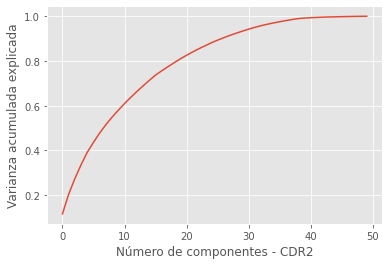

In [15]:
#graficamos el acumulado de varianza explicada en las nuevas dimensiones
plt.plot(np.cumsum(pcaCDR2.explained_variance_ratio_))
plt.xlabel('Número de componentes - CDR2')
plt.ylabel('Varianza acumulada explicada')
plt.show()

In [16]:
print("shape of X_pca2", principalCDR2.shape)
exp2 = pcaCDR2.explained_variance_ratio_
print(exp2)
print('suma:',sum(exp2[0:27]))

shape of X_pca2 (5937, 50)
[0.11577057 0.08747671 0.07027411 0.06176485 0.05636779 0.0442687
 0.04182018 0.03719387 0.03393489 0.03081186 0.02981761 0.02758336
 0.02650258 0.02527356 0.02459353 0.02351968 0.01914215 0.01832618
 0.01787867 0.01735687 0.01590045 0.01503441 0.01443335 0.0132785
 0.01321213 0.01173646 0.01105578 0.01035993 0.00965404 0.00921951
 0.00885174 0.00809855 0.00738363 0.00640668 0.00589474 0.00541419
 0.00501363 0.004892   0.0040334  0.00227815 0.00170419 0.00133589
 0.00119026 0.00078786 0.00065854 0.00063805 0.00057323 0.00052491
 0.0005156  0.0002425 ]
suma: 0.9043287919183823


In [17]:
pcaCDR3 = PCA(n_components=160)
principalComponentsCDR3 = pcaCDR3.fit_transform(xCDR3)
principalCDR3 = pd.DataFrame(data = principalComponentsCDR3
             , columns = ['CDR3-pc1', 'CDR3-pc2', 'CDR3-pc3', 'CDR3-pc4', 'CDR3-pc5',
                            'CDR3-pc6', 'CDR3-pc7', 'CDR3-pc8', 'CDR3-pc9', 'CDR3-pc10',
                            'CDR3-pc11', 'CDR3-pc12', 'CDR3-pc13', 'CDR3-pc14', 'CDR3-pc15',
                            'CDR3-pc16', 'CDR3-pc17', 'CDR3-pc18', 'CDR3-pc19', 'CDR3-pc20',
                            'CDR3-pc21', 'CDR3-pc22', 'CDR3-pc23', 'CDR3-pc24', 'CDR3-pc25',
                            'CDR3-pc26', 'CDR3-pc27', 'CDR3-pc28', 'CDR3-pc29', 'CDR3-pc30',
                            'CDR3-pc31', 'CDR3-pc32', 'CDR3-pc33', 'CDR3-pc34', 'CDR3-pc35',
                            'CDR3-pc36', 'CDR3-pc37', 'CDR3-pc38', 'CDR3-pc39', 'CDR3-pc40',
                            'CDR3-pc41', 'CDR3-pc42', 'CDR3-pc43', 'CDR3-pc44', 'CDR3-pc45',
                            'CDR3-pc46', 'CDR3-pc47', 'CDR3-pc48', 'CDR3-pc49', 'CDR3-pc50',
                            'CDR3-pc51', 'CDR3-pc52', 'CDR3-pc53', 'CDR3-pc54', 'CDR3-pc55',
                            'CDR3-pc56', 'CDR3-pc57', 'CDR3-pc58', 'CDR3-pc59', 'CDR3-pc60',
                            'CDR3-pc61', 'CDR3-pc62', 'CDR3-pc63', 'CDR3-pc64', 'CDR3-pc65',
                            'CDR3-pc66', 'CDR3-pc67', 'CDR3-pc68', 'CDR3-pc69', 'CDR3-pc70',
                            'CDR3-pc71', 'CDR3-pc72', 'CDR3-pc73', 'CDR3-pc74', 'CDR3-pc75',
                            'CDR3-pc76', 'CDR3-pc77', 'CDR3-pc78', 'CDR3-pc79', 'CDR3-pc80',
                            'CDR3-pc81', 'CDR3-pc82', 'CDR3-pc83', 'CDR3-pc84', 'CDR3-pc85',
                            'CDR3-pc86', 'CDR3-pc87', 'CDR3-pc88', 'CDR3-pc89', 'CDR3-pc90',
                            'CDR3-pc91', 'CDR3-pc92', 'CDR3-pc93', 'CDR3-pc94', 'CDR3-pc95',
                            'CDR3-pc96', 'CDR3-pc97', 'CDR3-pc98', 'CDR3-pc99', 'CDR3-pc100',
                            'CDR3-pc101', 'CDR3-pc102', 'CDR3-pc103', 'CDR3-pc104', 'CDR3-pc105',
                            'CDR3-pc106', 'CDR3-pc107', 'CDR3-pc108', 'CDR3-pc109', 'CDR3-pc110',
                            'CDR3-pc111', 'CDR3-pc112', 'CDR3-pc113', 'CDR3-pc114', 'CDR3-pc115',
                            'CDR3-pc116', 'CDR3-pc117', 'CDR3-pc118', 'CDR3-pc119', 'CDR3-pc120',
                            'CDR3-pc121', 'CDR3-pc122', 'CDR3-pc123', 'CDR3-pc124', 'CDR3-pc125',
                            'CDR3-pc126', 'CDR3-pc127', 'CDR3-pc128', 'CDR3-pc129', 'CDR3-pc130',
                            'CDR3-pc131', 'CDR3-pc132', 'CDR3-pc133', 'CDR3-pc134', 'CDR3-pc45',
                            'CDR3-pc136', 'CDR3-pc137', 'CDR3-pc138', 'CDR3-pc139', 'CDR3-pc140',
                            'CDR3-pc141', 'CDR3-pc142', 'CDR3-pc143', 'CDR3-pc144', 'CDR3-pc145',
                            'CDR3-pc146', 'CDR3-pc147', 'CDR3-pc148', 'CDR3-pc149', 'CDR3-pc150',
                            'CDR3-pc151', 'CDR3-pc152', 'CDR3-pc153', 'CDR3-pc154', 'CDR3-pc155',
                            'CDR3-pc156', 'CDR3-pc157', 'CDR3-pc158', 'CDR3-pc159', 'CDR3-pc160',
                            ])

principalCDR3

,CDR3-pc1,CDR3-pc2,CDR3-pc3,CDR3-pc4,CDR3-pc5,CDR3-pc6,CDR3-pc7,CDR3-pc8,CDR3-pc9,CDR3-pc10,...,CDR3-pc151,CDR3-pc152,CDR3-pc153,CDR3-pc154,CDR3-pc155,CDR3-pc156,CDR3-pc157,CDR3-pc158,CDR3-pc159,CDR3-pc160
0,-0.021123,0.043395,0.294396,-0.163911,-0.203727,0.024610,-0.050713,-0.412512,0.025082,-0.374422,...,6.446770e-16,-2.003259e-16,3.584748e-16,-6.211196e-16,5.652501e-16,-5.213874e-16,1.148188e-16,-6.453467e-16,-2.168486e-17,-2.718419e-16
1,-1.690280,2.140299,-11.565630,1.649403,-1.342345,1.403291,-0.417844,-7.355589,-3.433306,0.072724,...,1.377331e-15,1.016786e-15,-5.928853e-15,-1.017140e-15,6.024728e-16,-3.183319e-15,6.782445e-16,1.570795e-15,-1.888940e-15,1.311774e-15
2,-0.031217,-0.057610,-0.075136,0.013583,0.025483,-0.019124,-0.218282,0.034488,-0.172601,0.503656,...,-2.992554e-15,-1.258129e-15,-1.661381e-16,-2.548448e-15,3.632836e-15,-8.676791e-16,3.592534e-16,2.471731e-15,1.867343e-15,-6.864442e-17
3,0.023023,0.152298,0.173336,0.192947,-0.022298,0.320430,-0.042339,0.211787,-0.012227,-0.000848,...,2.629066e-15,6.876692e-15,1.765471e-15,-3.095127e-15,-3.161669e-15,4.092372e-16,-6.012518e-16,6.131982e-15,-1.312948e-15,-5.647172e-16
4,-0.071390,0.110154,0.091318,0.233874,0.138091,0.000687,-0.252541,0.079666,-0.205761,-0.182765,...,-4.373429e-16,-4.899914e-16,-4.543104e-16,-1.221968e-15,6.524306e-16,4.361498e-16,-4.687429e-16,3.058244e-16,5.348967e-16,-4.552310e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5932,-0.097489,0.110959,0.086850,-0.365001,-0.464922,-0.364412,1.019782,-1.143913,0.641045,-0.062669,...,3.322365e-17,4.765347e-17,-1.716685e-17,-1.860914e-18,-7.156152e-17,-1.708050e-17,-3.486926e-17,-2.509641e-17,2.659962e-17,-4.481659e-17
5933,-0.055989,0.092455,0.053842,-0.259113,0.038349,-0.177566,0.624701,-0.024697,0.563961,-1.615315,...,2.596308e-17,5.911741e-18,5.562985e-17,-7.076456e-17,-8.331627e-17,-4.416765e-17,2.043550e-17,-8.311166e-17,5.425161e-18,-9.853697e-18
5934,-1.137730,7.338975,12.545629,7.714783,-13.504529,15.137093,9.679173,10.335772,-1.070800,8.148797,...,-3.510213e-16,-1.809983e-16,-3.253157e-16,-1.486057e-16,-1.139416e-15,-2.199646e-16,2.086467e-16,-5.754657e-16,2.771333e-16,-2.369337e-16
5935,-0.017909,0.312384,0.345936,-0.269883,-0.587689,-0.744800,-1.233077,-0.795077,-1.785470,1.974043,...,-7.680055e-17,4.570235e-17,2.152060e-17,-1.236369e-16,-2.563916e-17,4.421181e-17,-6.031655e-17,-3.322323e-17,-1.831753e-17,-2.681055e-17


### PCA - RELACION DE VARIANZA CDR3

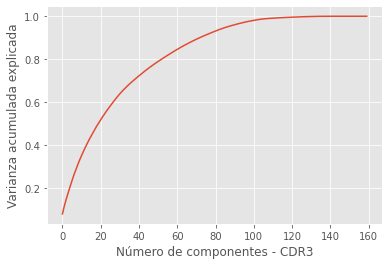

In [18]:
#graficamos el acumulado de varianza explicada en las nuevas dimensiones
plt.plot(np.cumsum(pcaCDR3.explained_variance_ratio_))
plt.xlabel('Número de componentes - CDR3')
plt.ylabel('Varianza acumulada explicada')
plt.show()

In [19]:
print("shape of X_pca3", principalCDR3.shape)
exp3 = pcaCDR3.explained_variance_ratio_
print(exp3)
print('suma:',sum(exp3[0:70]))
#Vemos que con 5 componentes tenemos algo mas del 85% de varianza explicada

shape of X_pca3 (5937, 160)
[7.79213237e-02 3.71204080e-02 3.17873793e-02 2.97784624e-02
 2.86514243e-02 2.78435116e-02 2.67920734e-02 2.37800303e-02
 2.31398452e-02 2.27262999e-02 2.10329390e-02 1.96327862e-02
 1.91322054e-02 1.83129215e-02 1.74463082e-02 1.64411368e-02
 1.60237499e-02 1.57830701e-02 1.55591942e-02 1.41803402e-02
 1.40567339e-02 1.38799099e-02 1.34308294e-02 1.28071713e-02
 1.26471375e-02 1.21129562e-02 1.19333911e-02 1.17429405e-02
 1.12762159e-02 1.07629489e-02 1.05350977e-02 9.94503622e-03
 9.49296578e-03 9.16096046e-03 8.51037592e-03 8.32157233e-03
 8.10848225e-03 7.81437280e-03 7.67814991e-03 7.52452073e-03
 7.42828521e-03 7.35748472e-03 7.24785036e-03 7.03241973e-03
 7.01079506e-03 6.78067021e-03 6.52407184e-03 6.44841521e-03
 6.28118260e-03 6.20037653e-03 6.02038657e-03 5.94919829e-03
 5.92234035e-03 5.86011952e-03 5.77319540e-03 5.66399376e-03
 5.62265575e-03 5.55249984e-03 5.45863361e-03 5.38982086e-03
 5.27848608e-03 5.21947194e-03 5.06592198e-03 5.02358435e

### PCA - SELECCION DE LOS COMPONENTES CDR1, CDR2 Y CDR3 

In [20]:
pcaCDR1_27 = PCA(n_components=27)
principalComponentsCDR1_VF = pcaCDR1_27.fit_transform(xCDR1)
principalCDR1_VF = pd.DataFrame(data = principalComponentsCDR1_VF
             , columns = ['CDR1-pc1', 'CDR1-pc2', 'CDR1-pc3', 'CDR1-pc4', 'CDR1-pc5',
                          'CDR1-pc6', 'CDR1-pc7', 'CDR1-pc8', 'CDR1-pc9', 'CDR1-pc10',
                          'CDR1-pc11', 'CDR1-pc12', 'CDR1-pc13', 'CDR1-pc14', 'CDR1-pc15',
                          'CDR1-pc16', 'CDR1-pc17', 'CDR1-pc18', 'CDR1-pc19', 'CDR1-pc20',
                          'CDR1-pc21', 'CDR1-pc22', 'CDR1-pc23', 'CDR1-pc24', 'CDR1-pc25',
                          'CDR1-pc26', 'CDR1-pc27',
                         ])

principalCDR1_VF

,CDR1-pc1,CDR1-pc2,CDR1-pc3,CDR1-pc4,CDR1-pc5,CDR1-pc6,CDR1-pc7,CDR1-pc8,CDR1-pc9,CDR1-pc10,...,CDR1-pc18,CDR1-pc19,CDR1-pc20,CDR1-pc21,CDR1-pc22,CDR1-pc23,CDR1-pc24,CDR1-pc25,CDR1-pc26,CDR1-pc27
0,0.267629,-0.562812,2.523779,0.876651,2.934049,-0.875608,0.390973,-2.124544,-2.932846,1.120663,...,0.395505,-0.016238,-0.541465,-0.579394,0.118221,0.443444,2.376019,-0.635915,-0.538832,1.358517
1,-0.337665,1.301852,-1.245905,0.151871,-1.225956,-2.565975,0.466223,-1.429170,-0.758620,-1.193198,...,-0.874517,0.033893,0.371529,0.421217,0.567112,0.373648,-0.619029,0.160025,-0.119760,0.347503
2,-0.000438,0.058983,1.979043,1.398143,2.362599,-1.326047,0.377343,-1.794948,-3.218358,0.243883,...,0.027752,-0.184059,-0.066640,-0.651947,0.051407,-0.462987,-0.259621,-0.167519,0.169081,-0.225838
3,0.204282,-0.520909,2.463982,1.085190,2.987214,-0.736513,0.402246,-2.201579,-2.515383,1.391987,...,-0.570952,-0.616190,-0.272171,-0.345987,-1.101541,0.259681,-0.030943,-0.373329,-0.177801,0.328279
4,-0.000438,0.058983,1.979043,1.398143,2.362599,-1.326047,0.377343,-1.794948,-3.218358,0.243883,...,0.027752,-0.184059,-0.066640,-0.651947,0.051407,-0.462987,-0.259621,-0.167519,0.169081,-0.225838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5932,-0.320667,1.264701,-1.168610,0.077150,-1.370118,-3.085446,0.376836,-1.161115,-1.149854,-1.096331,...,-0.273402,0.205153,0.200032,0.317483,-0.133314,-0.260883,-0.122482,-0.089709,0.313441,-0.424964
5933,-0.022412,0.368659,2.423742,1.194574,0.987679,-1.690835,0.076570,-0.102477,-2.095151,0.822433,...,-0.361862,-1.469450,-0.707882,0.240693,0.500938,-1.207978,0.005010,0.207973,0.991224,-0.381279
5934,-0.395404,1.573719,-0.610919,0.700559,1.604524,-0.201799,-0.020773,0.542752,-1.421124,0.854352,...,0.091804,0.784161,0.391247,0.433740,-0.192871,0.443477,-0.167866,0.041651,0.190795,-0.345234
5935,-0.028928,-0.252381,-0.398732,0.745975,1.833171,1.805557,0.093968,-0.684084,0.552070,-3.124612,...,-0.965951,1.153721,0.024785,-0.963968,0.136248,-0.195616,0.017377,0.035973,1.333438,-0.199163


In [21]:
pcaCDR2_27 = PCA(n_components=27)
principalComponentsCDR2_VF = pcaCDR2_27.fit_transform(xCDR2)
principalCDR2_VF = pd.DataFrame(data = principalComponentsCDR2_VF
             , columns = ['CDR2-pc1', 'CDR2-pc2', 'CDR2-pc3', 'CDR2-pc4', 'CDR2-pc5',
                          'CDR2-pc6', 'CDR2-pc7', 'CDR2-pc8', 'CDR2-pc9', 'CDR2-pc10',
                          'CDR2-pc11', 'CDR2-pc12', 'CDR2-pc13', 'CDR2-pc14', 'CDR2-pc15',
                          'CDR2-pc16', 'CDR2-pc17', 'CDR2-pc18', 'CDR2-pc19', 'CDR2-pc20',
                          'CDR2-pc21', 'CDR2-pc22', 'CDR2-pc23', 'CDR2-pc24', 'CDR2-pc25',
                          'CDR2-pc26', 'CDR2-pc27',
                         ])

principalCDR2_VF

,CDR2-pc1,CDR2-pc2,CDR2-pc3,CDR2-pc4,CDR2-pc5,CDR2-pc6,CDR2-pc7,CDR2-pc8,CDR2-pc9,CDR2-pc10,...,CDR2-pc18,CDR2-pc19,CDR2-pc20,CDR2-pc21,CDR2-pc22,CDR2-pc23,CDR2-pc24,CDR2-pc25,CDR2-pc26,CDR2-pc27
0,0.007060,0.392422,2.646801,-0.402483,-2.011361,0.457948,1.935763,1.028524,-0.459991,-0.913153,...,-0.366332,0.485601,-0.376555,0.139167,0.478961,0.114606,-0.373506,-0.326752,-0.166035,-0.189555
1,-0.514524,-2.841126,-2.257054,0.143033,1.010689,-1.207448,-1.085168,0.399830,-0.174418,-0.219926,...,1.576966,-0.058246,-0.415713,0.019134,0.251311,0.675092,1.038562,0.056790,0.198462,0.457477
2,0.007060,0.392422,2.646801,-0.402483,-2.011361,0.457948,1.935763,1.028524,-0.459991,-0.913153,...,-0.366332,0.485601,-0.376555,0.139167,0.478961,0.114606,-0.373506,-0.326752,-0.166035,-0.189555
3,0.007060,0.392422,2.646801,-0.402483,-2.011361,0.457948,1.935763,1.028524,-0.459991,-0.913153,...,-0.366332,0.485601,-0.376555,0.139167,0.478961,0.114606,-0.373506,-0.326752,-0.166035,-0.189555
4,0.010768,0.293448,2.591440,-0.302539,-2.325784,0.353492,1.726014,0.863321,-0.311190,-1.067400,...,-0.320047,0.653614,-0.402590,-0.452766,0.757198,-0.167113,-0.120527,-0.420840,-0.154713,-0.066818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5932,-0.394154,-0.449634,0.711875,-2.711375,-1.327290,0.930305,0.211343,-0.219558,0.311408,-2.086118,...,0.001677,0.692004,0.114748,0.452536,0.362677,1.157283,0.289671,0.065400,0.113790,0.125803
5933,-0.606449,-0.610932,-0.225513,-1.412968,1.031858,-1.933683,-0.537138,0.199930,0.464001,-0.505454,...,2.011305,-0.738133,0.797562,0.171723,-0.259031,-1.731883,-1.519191,-1.189163,-0.807496,-0.089630
5934,-1.058647,-2.087001,-1.168668,-0.278065,0.162084,-0.734265,2.382455,0.418768,0.420744,0.856334,...,-1.099529,-0.356172,0.814429,0.841764,-0.594972,-1.024917,-0.855721,-0.814398,-0.302176,-0.322395
5935,-0.823344,-3.687466,0.594013,-0.015280,0.348666,-1.751187,0.717397,0.647362,0.292093,0.178760,...,-0.299780,0.663589,-2.918480,-1.392941,-1.276300,-0.675313,0.100353,-0.760353,-0.452413,-0.017826


In [22]:
pcaCDR3_70 = PCA(n_components=70)
principalComponentsCDR3_VF = pcaCDR3_70.fit_transform(xCDR3)
principalCDR3_VF = pd.DataFrame(data = principalComponentsCDR3_VF
             , columns = ['CDR3-pc1', 'CDR3-pc2', 'CDR3-pc3', 'CDR3-pc4', 'CDR3-pc5',
                            'CDR3-pc6', 'CDR3-pc7', 'CDR3-pc8', 'CDR3-pc9', 'CDR3-pc10',
                            'CDR3-pc11', 'CDR3-pc12', 'CDR3-pc13', 'CDR3-pc14', 'CDR3-pc15',
                            'CDR3-pc16', 'CDR3-pc17', 'CDR3-pc18', 'CDR3-pc19', 'CDR3-pc20',
                            'CDR3-pc21', 'CDR3-pc22', 'CDR3-pc23', 'CDR3-pc24', 'CDR3-pc25',
                            'CDR3-pc26', 'CDR3-pc27', 'CDR3-pc28', 'CDR3-pc29', 'CDR3-pc30',
                            'CDR3-pc31', 'CDR3-pc32', 'CDR3-pc33', 'CDR3-pc34', 'CDR3-pc35',
                            'CDR3-pc36', 'CDR3-pc37', 'CDR3-pc38', 'CDR3-pc39', 'CDR3-pc40',
                            'CDR3-pc41', 'CDR3-pc42', 'CDR3-pc43', 'CDR3-pc44', 'CDR3-pc45',
                            'CDR3-pc46', 'CDR3-pc47', 'CDR3-pc48', 'CDR3-pc49', 'CDR3-pc50',
                            'CDR3-pc51', 'CDR3-pc52', 'CDR3-pc53', 'CDR3-pc54', 'CDR3-pc55',
                            'CDR3-pc56', 'CDR3-pc57', 'CDR3-pc58', 'CDR3-pc59', 'CDR3-pc60',
                            'CDR3-pc61', 'CDR3-pc62', 'CDR3-pc63', 'CDR3-pc64', 'CDR3-pc65',
                            'CDR3-pc66', 'CDR3-pc67', 'CDR3-pc68', 'CDR3-pc69', 'CDR3-pc70',
                            ])

principalCDR3_VF

,CDR3-pc1,CDR3-pc2,CDR3-pc3,CDR3-pc4,CDR3-pc5,CDR3-pc6,CDR3-pc7,CDR3-pc8,CDR3-pc9,CDR3-pc10,...,CDR3-pc61,CDR3-pc62,CDR3-pc63,CDR3-pc64,CDR3-pc65,CDR3-pc66,CDR3-pc67,CDR3-pc68,CDR3-pc69,CDR3-pc70
0,-0.021121,0.043424,0.294370,-0.163939,-0.203662,0.024529,-0.050649,-0.412752,0.024976,-0.374242,...,0.291935,-0.171377,-0.942781,-0.153321,0.537891,0.230199,0.270297,-0.136614,-0.650215,0.182947
1,-1.690277,2.140307,-11.565744,1.649227,-1.342235,1.402794,-0.417681,-7.355834,-3.434131,0.072924,...,-0.040110,-0.152876,-0.248357,-0.006786,0.446930,-0.352109,0.940420,0.257412,0.826492,-1.010937
2,-0.031216,-0.057586,-0.075161,0.013509,0.025498,-0.019146,-0.218249,0.034501,-0.172522,0.503696,...,0.037449,0.542221,-0.150105,-0.204790,0.369141,0.584211,0.500649,-0.307554,-0.308658,0.568008
3,0.023024,0.152338,0.173350,0.192928,-0.022301,0.320418,-0.042289,0.211565,-0.012194,-0.000720,...,0.257253,0.120274,-0.485919,-0.026746,0.302518,0.142926,-0.321409,0.427928,-0.680533,0.436826
4,-0.071392,0.110115,0.091363,0.233990,0.138031,0.000781,-0.252641,0.079796,-0.205661,-0.182960,...,0.737697,-0.146234,0.068856,0.323405,-0.196278,-0.893413,-0.234062,-0.247100,0.011743,-0.310256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5932,-0.097487,0.110985,0.086772,-0.365138,-0.464901,-0.364566,1.019830,-1.143985,0.640819,-0.062611,...,0.366214,0.057553,-0.250583,-0.122055,0.525081,-0.053113,-0.600676,-1.096342,-0.001628,-0.755168
5933,-0.055988,0.092447,0.053822,-0.259114,0.038415,-0.177664,0.624697,-0.024884,0.563751,-1.615231,...,-2.558799,1.163252,0.449142,1.285272,-0.358586,0.581499,-0.274551,1.192760,0.307049,-0.787602
5934,-1.137742,7.339100,12.545916,7.714807,-13.504907,15.138011,9.678890,10.337665,-1.069190,8.148030,...,-0.874229,-0.258762,1.376298,-0.603646,1.763133,-0.643452,2.207532,-1.938561,0.160276,0.566651
5935,-0.017906,0.312409,0.345938,-0.270011,-0.587800,-0.745070,-1.232983,-0.795242,-1.785830,1.974103,...,-0.681732,-0.931315,1.537637,0.433748,-1.972738,-0.660785,1.402559,-0.061082,2.351371,0.438434


In [23]:
df = df.drop(['cdr1.cad.I.heavy.0', 'cdr1.cad.I.heavy.1', 'cdr1.cad.I.heavy.2', 
                'cdr1.cad.I.heavy.3', 'cdr1.cad.I.heavy.4', 'cdr1.cad.I.heavy.5', 
                'cdr1.cad.I.heavy.6', 'cdr1.cad.I.heavy.7', 'cdr1.cad.I.heavy.8', 
                'cdr1.cad.I.heavy.9', 'cdr1.cad.I.heavy.10', 'cdr1.cad.I.heavy.11', 
                
                'cdr1.cad.II.heavy.0', 'cdr1.cad.II.heavy.1', 'cdr1.cad.II.heavy.2',
                'cdr1.cad.II.heavy.3', 'cdr1.cad.II.heavy.4', 'cdr1.cad.II.heavy.5',
                'cdr1.cad.II.heavy.6', 'cdr1.cad.II.heavy.7', 'cdr1.cad.II.heavy.8',
                'cdr1.cad.II.heavy.9', 'cdr1.cad.II.heavy.10', 'cdr1.cad.II.heavy.11',
                
                'cdr1.cad.III.heavy.0', 'cdr1.cad.III.heavy.1', 'cdr1.cad.III.heavy.2',
                'cdr1.cad.III.heavy.3', 'cdr1.cad.III.heavy.4', 'cdr1.cad.III.heavy.5',
                'cdr1.cad.III.heavy.6', 'cdr1.cad.III.heavy.7', 'cdr1.cad.III.heavy.8',
                'cdr1.cad.III.heavy.9', 'cdr1.cad.III.heavy.10', 'cdr1.cad.III.heavy.11',
                
                'cdr1.cad.IV.heavy.0', 'cdr1.cad.IV.heavy.1', 'cdr1.cad.IV.heavy.2',
                'cdr1.cad.IV.heavy.3', 'cdr1.cad.IV.heavy.4', 'cdr1.cad.IV.heavy.5',
                'cdr1.cad.IV.heavy.6', 'cdr1.cad.IV.heavy.7', 'cdr1.cad.IV.heavy.8',
                'cdr1.cad.IV.heavy.9', 'cdr1.cad.IV.heavy.10', 'cdr1.cad.IV.heavy.11',
                
                'cdr1.cad.V.heavy.0', 'cdr1.cad.V.heavy.1', 'cdr1.cad.V.heavy.2',
                'cdr1.cad.V.heavy.3', 'cdr1.cad.V.heavy.4', 'cdr1.cad.V.heavy.5',
                'cdr1.cad.V.heavy.6', 'cdr1.cad.V.heavy.7', 'cdr1.cad.V.heavy.8',
                'cdr1.cad.V.heavy.9', 'cdr1.cad.V.heavy.10', 'cdr1.cad.V.heavy.11',], axis=1)
df

,Class,VJ.length.heavy,V.length.heavy,CDR1.length.aa.heavy,CDR2.length.aa.heavy,CDR3.length.aa.heavy,N1.length.heavy,N2.length.heavy,P3V.length.heavy,P5D.length.heavy,...,cdr3.cad.V.heavy.26,cdr3.cad.V.heavy.27,cdr3.cad.V.heavy.28,cdr3.cad.V.heavy.29,cdr3.cad.V.heavy.30,cdr3.cad.V.heavy.31,V.GENE.heavy,J.GENE.heavy,D.GENE.heavy,VJ.GENE.heavy
0,Neutralizing,347.0,285.0,8.0,7.0,14,0.0,14.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,1,1,1,1
1,Neutralizing,350.0,288.0,8.0,8.0,25,1.0,4.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,2,1,2,2
2,Neutralizing,333.0,285.0,8.0,7.0,15,6.0,2.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,1,2,3,3
3,Neutralizing,343.0,285.0,8.0,7.0,13,2.0,1.0,1.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,3,1,4,4
4,Neutralizing,332.0,285.0,8.0,7.0,13,0.0,2.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,3,2,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5932,Neutralizing,350.0,288.0,8.0,8.0,17,3.0,5.0,2.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,7,1,21,146
5933,Neutralizing,335.0,285.0,8.0,7.0,16,0.0,13.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,35,4,11,60
5934,Neutralizing,350.0,288.0,8.0,8.0,27,16.0,10.0,0.0,0.0,...,-0.184,0.0,0.0,0.0,0.0,0.0,28,1,16,121
5935,Neutralizing,337.0,288.0,8.0,8.0,18,4.0,4.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,23,3,14,37


In [24]:
df = df.drop(['cdr2.cad.I.heavy.0', 'cdr2.cad.I.heavy.1', 'cdr2.cad.I.heavy.2', 
                'cdr2.cad.I.heavy.3', 'cdr2.cad.I.heavy.4', 'cdr2.cad.I.heavy.5', 
                'cdr2.cad.I.heavy.6', 'cdr2.cad.I.heavy.7', 'cdr2.cad.I.heavy.8', 'cdr2.cad.I.heavy.9',
                
                'cdr2.cad.II.heavy.0', 'cdr2.cad.II.heavy.1', 'cdr2.cad.II.heavy.2',
                'cdr2.cad.II.heavy.3', 'cdr2.cad.II.heavy.4', 'cdr2.cad.II.heavy.5',
                'cdr2.cad.II.heavy.6', 'cdr2.cad.II.heavy.7', 'cdr2.cad.II.heavy.8', 'cdr2.cad.II.heavy.9',
                
                'cdr2.cad.III.heavy.0', 'cdr2.cad.III.heavy.1', 'cdr2.cad.III.heavy.2',
                'cdr2.cad.III.heavy.3', 'cdr2.cad.III.heavy.4', 'cdr2.cad.III.heavy.5',
                'cdr2.cad.III.heavy.6', 'cdr2.cad.III.heavy.7', 'cdr2.cad.III.heavy.8', 'cdr2.cad.III.heavy.9',
                
                'cdr2.cad.IV.heavy.0', 'cdr2.cad.IV.heavy.1', 'cdr2.cad.IV.heavy.2',
                'cdr2.cad.IV.heavy.3', 'cdr2.cad.IV.heavy.4', 'cdr2.cad.IV.heavy.5',
                'cdr2.cad.IV.heavy.6', 'cdr2.cad.IV.heavy.7', 'cdr2.cad.IV.heavy.8', 'cdr2.cad.IV.heavy.9',
                
                'cdr2.cad.V.heavy.0', 'cdr2.cad.V.heavy.1', 'cdr2.cad.V.heavy.2',
                'cdr2.cad.V.heavy.3', 'cdr2.cad.V.heavy.4', 'cdr2.cad.V.heavy.5', 
                'cdr2.cad.V.heavy.6', 'cdr2.cad.V.heavy.7', 'cdr2.cad.V.heavy.8', 'cdr2.cad.V.heavy.9',], axis=1)
df

,Class,VJ.length.heavy,V.length.heavy,CDR1.length.aa.heavy,CDR2.length.aa.heavy,CDR3.length.aa.heavy,N1.length.heavy,N2.length.heavy,P3V.length.heavy,P5D.length.heavy,...,cdr3.cad.V.heavy.26,cdr3.cad.V.heavy.27,cdr3.cad.V.heavy.28,cdr3.cad.V.heavy.29,cdr3.cad.V.heavy.30,cdr3.cad.V.heavy.31,V.GENE.heavy,J.GENE.heavy,D.GENE.heavy,VJ.GENE.heavy
0,Neutralizing,347.0,285.0,8.0,7.0,14,0.0,14.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,1,1,1,1
1,Neutralizing,350.0,288.0,8.0,8.0,25,1.0,4.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,2,1,2,2
2,Neutralizing,333.0,285.0,8.0,7.0,15,6.0,2.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,1,2,3,3
3,Neutralizing,343.0,285.0,8.0,7.0,13,2.0,1.0,1.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,3,1,4,4
4,Neutralizing,332.0,285.0,8.0,7.0,13,0.0,2.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,3,2,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5932,Neutralizing,350.0,288.0,8.0,8.0,17,3.0,5.0,2.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,7,1,21,146
5933,Neutralizing,335.0,285.0,8.0,7.0,16,0.0,13.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,35,4,11,60
5934,Neutralizing,350.0,288.0,8.0,8.0,27,16.0,10.0,0.0,0.0,...,-0.184,0.0,0.0,0.0,0.0,0.0,28,1,16,121
5935,Neutralizing,337.0,288.0,8.0,8.0,18,4.0,4.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,0.0,23,3,14,37


In [25]:
df = df.drop(['cdr3.cad.I.heavy.0', 'cdr3.cad.I.heavy.1', 'cdr3.cad.I.heavy.2', 'cdr3.cad.I.heavy.3',
                'cdr3.cad.I.heavy.4', 'cdr3.cad.I.heavy.5', 'cdr3.cad.I.heavy.6', 'cdr3.cad.I.heavy.7',
                'cdr3.cad.I.heavy.8', 'cdr3.cad.I.heavy.9', 'cdr3.cad.I.heavy.10', 'cdr3.cad.I.heavy.11',
                'cdr3.cad.I.heavy.12', 'cdr3.cad.I.heavy.13', 'cdr3.cad.I.heavy.14', 'cdr3.cad.I.heavy.15',
                'cdr3.cad.I.heavy.16', 'cdr3.cad.I.heavy.17', 'cdr3.cad.I.heavy.18', 'cdr3.cad.I.heavy.19',
                'cdr3.cad.I.heavy.20', 'cdr3.cad.I.heavy.21', 'cdr3.cad.I.heavy.22', 'cdr3.cad.I.heavy.23',
                'cdr3.cad.I.heavy.24', 'cdr3.cad.I.heavy.25', 'cdr3.cad.I.heavy.26', 'cdr3.cad.I.heavy.27',
                'cdr3.cad.I.heavy.28', 'cdr3.cad.I.heavy.29', 'cdr3.cad.I.heavy.30', 'cdr3.cad.I.heavy.31',

                'cdr3.cad.II.heavy.0', 'cdr3.cad.II.heavy.1', 'cdr3.cad.II.heavy.2', 'cdr3.cad.II.heavy.3',
                'cdr3.cad.II.heavy.4', 'cdr3.cad.II.heavy.5', 'cdr3.cad.II.heavy.6', 'cdr3.cad.II.heavy.7',
                'cdr3.cad.II.heavy.8', 'cdr3.cad.II.heavy.9', 'cdr3.cad.II.heavy.10', 'cdr3.cad.II.heavy.11',
                'cdr3.cad.II.heavy.12', 'cdr3.cad.II.heavy.13', 'cdr3.cad.II.heavy.14', 'cdr3.cad.II.heavy.15',
                'cdr3.cad.II.heavy.16', 'cdr3.cad.II.heavy.17', 'cdr3.cad.II.heavy.18', 'cdr3.cad.II.heavy.19',
                'cdr3.cad.II.heavy.20', 'cdr3.cad.II.heavy.21', 'cdr3.cad.II.heavy.22', 'cdr3.cad.II.heavy.23',
                'cdr3.cad.II.heavy.24', 'cdr3.cad.II.heavy.25', 'cdr3.cad.II.heavy.26', 'cdr3.cad.II.heavy.27',
                'cdr3.cad.II.heavy.28', 'cdr3.cad.II.heavy.29', 'cdr3.cad.II.heavy.30', 'cdr3.cad.II.heavy.31',

                'cdr3.cad.III.heavy.0', 'cdr3.cad.III.heavy.1', 'cdr3.cad.III.heavy.2', 'cdr3.cad.III.heavy.3',
                'cdr3.cad.III.heavy.4', 'cdr3.cad.III.heavy.5', 'cdr3.cad.III.heavy.6', 'cdr3.cad.III.heavy.7',
                'cdr3.cad.III.heavy.8', 'cdr3.cad.III.heavy.9', 'cdr3.cad.III.heavy.10', 'cdr3.cad.III.heavy.11',
                'cdr3.cad.III.heavy.12', 'cdr3.cad.III.heavy.13', 'cdr3.cad.III.heavy.14', 'cdr3.cad.III.heavy.15',
                'cdr3.cad.III.heavy.16', 'cdr3.cad.III.heavy.17', 'cdr3.cad.III.heavy.18', 'cdr3.cad.III.heavy.19',
                'cdr3.cad.III.heavy.20', 'cdr3.cad.III.heavy.21', 'cdr3.cad.III.heavy.22', 'cdr3.cad.III.heavy.23',
                'cdr3.cad.III.heavy.24', 'cdr3.cad.III.heavy.25', 'cdr3.cad.III.heavy.26', 'cdr3.cad.III.heavy.27',
                'cdr3.cad.III.heavy.28', 'cdr3.cad.III.heavy.29', 'cdr3.cad.III.heavy.30', 'cdr3.cad.III.heavy.31',

                'cdr3.cad.IV.heavy.0', 'cdr3.cad.IV.heavy.1', 'cdr3.cad.IV.heavy.2', 'cdr3.cad.IV.heavy.3',
                'cdr3.cad.IV.heavy.4', 'cdr3.cad.IV.heavy.5', 'cdr3.cad.IV.heavy.6', 'cdr3.cad.IV.heavy.7',
                'cdr3.cad.IV.heavy.8', 'cdr3.cad.IV.heavy.9', 'cdr3.cad.IV.heavy.10', 'cdr3.cad.IV.heavy.11',
                'cdr3.cad.IV.heavy.12', 'cdr3.cad.IV.heavy.13', 'cdr3.cad.IV.heavy.14', 'cdr3.cad.IV.heavy.15',
                'cdr3.cad.IV.heavy.16', 'cdr3.cad.IV.heavy.17', 'cdr3.cad.IV.heavy.18', 'cdr3.cad.IV.heavy.19',
                'cdr3.cad.IV.heavy.20', 'cdr3.cad.IV.heavy.21', 'cdr3.cad.IV.heavy.22', 'cdr3.cad.IV.heavy.23',
                'cdr3.cad.IV.heavy.24', 'cdr3.cad.IV.heavy.25', 'cdr3.cad.IV.heavy.26', 'cdr3.cad.IV.heavy.27',
                'cdr3.cad.IV.heavy.28', 'cdr3.cad.IV.heavy.29', 'cdr3.cad.IV.heavy.30', 'cdr3.cad.IV.heavy.31',

                'cdr3.cad.V.heavy.0', 'cdr3.cad.V.heavy.1', 'cdr3.cad.V.heavy.2', 'cdr3.cad.V.heavy.3',
                'cdr3.cad.V.heavy.4', 'cdr3.cad.V.heavy.5', 'cdr3.cad.V.heavy.6', 'cdr3.cad.V.heavy.7',
                'cdr3.cad.V.heavy.8', 'cdr3.cad.V.heavy.9', 'cdr3.cad.V.heavy.10', 'cdr3.cad.V.heavy.11',
                'cdr3.cad.V.heavy.12', 'cdr3.cad.V.heavy.13', 'cdr3.cad.V.heavy.14', 'cdr3.cad.V.heavy.15',
                'cdr3.cad.V.heavy.16', 'cdr3.cad.V.heavy.17', 'cdr3.cad.V.heavy.18', 'cdr3.cad.V.heavy.19',
                'cdr3.cad.V.heavy.20', 'cdr3.cad.V.heavy.21', 'cdr3.cad.V.heavy.22', 'cdr3.cad.V.heavy.23', 
                'cdr3.cad.V.heavy.24', 'cdr3.cad.V.heavy.25', 'cdr3.cad.V.heavy.26', 'cdr3.cad.V.heavy.27',
                'cdr3.cad.V.heavy.28', 'cdr3.cad.V.heavy.29', 'cdr3.cad.V.heavy.30', 'cdr3.cad.V.heavy.31',], axis=1)
df

,Class,VJ.length.heavy,V.length.heavy,CDR1.length.aa.heavy,CDR2.length.aa.heavy,CDR3.length.aa.heavy,N1.length.heavy,N2.length.heavy,P3V.length.heavy,P5D.length.heavy,...,cdr3.mean.cad.V.heavy,cdr3.sd.cad.I.heavy,cdr3.sd.cad.II.heavy,cdr3.sd.cad.III.heavy,cdr3.sd.cad.IV.heavy,cdr3.sd.cad.V.heavy,V.GENE.heavy,J.GENE.heavy,D.GENE.heavy,VJ.GENE.heavy
0,Neutralizing,347.0,285.0,8.0,7.0,14,0.0,14.0,0.0,0.0,...,-0.582643,0.994277,0.994596,2.257378,1.103798,2.081136,1,1,1,1
1,Neutralizing,350.0,288.0,8.0,8.0,25,1.0,4.0,0.0,0.0,...,0.425440,0.773515,0.954202,2.614451,1.011290,1.787852,2,1,2,2
2,Neutralizing,333.0,285.0,8.0,7.0,15,6.0,2.0,0.0,0.0,...,-0.055867,0.902415,1.043997,2.292955,1.117883,1.837475,1,2,3,3
3,Neutralizing,343.0,285.0,8.0,7.0,13,2.0,1.0,1.0,0.0,...,-0.629692,1.060486,0.801567,2.097305,1.142792,1.963943,3,1,4,4
4,Neutralizing,332.0,285.0,8.0,7.0,13,0.0,2.0,0.0,0.0,...,-0.101077,0.938036,0.805761,2.589105,1.036866,2.082300,3,2,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5932,Neutralizing,350.0,288.0,8.0,8.0,17,3.0,5.0,2.0,0.0,...,0.210706,1.059848,0.857962,1.824057,1.129363,1.734456,7,1,21,146
5933,Neutralizing,335.0,285.0,8.0,7.0,16,0.0,13.0,0.0,0.0,...,-0.640500,0.898661,0.872311,1.646348,1.190859,1.524972,35,4,11,60
5934,Neutralizing,350.0,288.0,8.0,8.0,27,16.0,10.0,0.0,0.0,...,-0.537370,0.748201,0.973695,2.765732,0.983485,1.927375,28,1,16,121
5935,Neutralizing,337.0,288.0,8.0,8.0,18,4.0,4.0,0.0,0.0,...,0.102333,0.891995,1.032438,2.101577,1.054722,1.541812,23,3,14,37


### CONCATENAR COMPONENETES AL DF

In [26]:
finalDf = pd.concat([df, principalCDR1_VF, principalCDR2_VF, principalCDR3_VF], axis = 1)
finalDf

,Class,VJ.length.heavy,V.length.heavy,CDR1.length.aa.heavy,CDR2.length.aa.heavy,CDR3.length.aa.heavy,N1.length.heavy,N2.length.heavy,P3V.length.heavy,P5D.length.heavy,...,CDR3-pc61,CDR3-pc62,CDR3-pc63,CDR3-pc64,CDR3-pc65,CDR3-pc66,CDR3-pc67,CDR3-pc68,CDR3-pc69,CDR3-pc70
0,Neutralizing,347.0,285.0,8.0,7.0,14,0.0,14.0,0.0,0.0,...,0.291935,-0.171377,-0.942781,-0.153321,0.537891,0.230199,0.270297,-0.136614,-0.650215,0.182947
1,Neutralizing,350.0,288.0,8.0,8.0,25,1.0,4.0,0.0,0.0,...,-0.040110,-0.152876,-0.248357,-0.006786,0.446930,-0.352109,0.940420,0.257412,0.826492,-1.010937
2,Neutralizing,333.0,285.0,8.0,7.0,15,6.0,2.0,0.0,0.0,...,0.037449,0.542221,-0.150105,-0.204790,0.369141,0.584211,0.500649,-0.307554,-0.308658,0.568008
3,Neutralizing,343.0,285.0,8.0,7.0,13,2.0,1.0,1.0,0.0,...,0.257253,0.120274,-0.485919,-0.026746,0.302518,0.142926,-0.321409,0.427928,-0.680533,0.436826
4,Neutralizing,332.0,285.0,8.0,7.0,13,0.0,2.0,0.0,0.0,...,0.737697,-0.146234,0.068856,0.323405,-0.196278,-0.893413,-0.234062,-0.247100,0.011743,-0.310256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5932,Neutralizing,350.0,288.0,8.0,8.0,17,3.0,5.0,2.0,0.0,...,0.366214,0.057553,-0.250583,-0.122055,0.525081,-0.053113,-0.600676,-1.096342,-0.001628,-0.755168
5933,Neutralizing,335.0,285.0,8.0,7.0,16,0.0,13.0,0.0,0.0,...,-2.558799,1.163252,0.449142,1.285272,-0.358586,0.581499,-0.274551,1.192760,0.307049,-0.787602
5934,Neutralizing,350.0,288.0,8.0,8.0,27,16.0,10.0,0.0,0.0,...,-0.874229,-0.258762,1.376298,-0.603646,1.763133,-0.643452,2.207532,-1.938561,0.160276,0.566651
5935,Neutralizing,337.0,288.0,8.0,8.0,18,4.0,4.0,0.0,0.0,...,-0.681732,-0.931315,1.537637,0.433748,-1.972738,-0.660785,1.402559,-0.061082,2.351371,0.438434


### REEMPLAZO DE ETIQUETAS DESTINO 

In [27]:
finalDf['Class'] = finalDf['Class'].replace({'Neutralizing':0,'No Neutralizing':1, 'Healthy':2 }, inplace=False)
finalDf

,Class,VJ.length.heavy,V.length.heavy,CDR1.length.aa.heavy,CDR2.length.aa.heavy,CDR3.length.aa.heavy,N1.length.heavy,N2.length.heavy,P3V.length.heavy,P5D.length.heavy,...,CDR3-pc61,CDR3-pc62,CDR3-pc63,CDR3-pc64,CDR3-pc65,CDR3-pc66,CDR3-pc67,CDR3-pc68,CDR3-pc69,CDR3-pc70
0,0,347.0,285.0,8.0,7.0,14,0.0,14.0,0.0,0.0,...,0.291935,-0.171377,-0.942781,-0.153321,0.537891,0.230199,0.270297,-0.136614,-0.650215,0.182947
1,0,350.0,288.0,8.0,8.0,25,1.0,4.0,0.0,0.0,...,-0.040110,-0.152876,-0.248357,-0.006786,0.446930,-0.352109,0.940420,0.257412,0.826492,-1.010937
2,0,333.0,285.0,8.0,7.0,15,6.0,2.0,0.0,0.0,...,0.037449,0.542221,-0.150105,-0.204790,0.369141,0.584211,0.500649,-0.307554,-0.308658,0.568008
3,0,343.0,285.0,8.0,7.0,13,2.0,1.0,1.0,0.0,...,0.257253,0.120274,-0.485919,-0.026746,0.302518,0.142926,-0.321409,0.427928,-0.680533,0.436826
4,0,332.0,285.0,8.0,7.0,13,0.0,2.0,0.0,0.0,...,0.737697,-0.146234,0.068856,0.323405,-0.196278,-0.893413,-0.234062,-0.247100,0.011743,-0.310256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5932,0,350.0,288.0,8.0,8.0,17,3.0,5.0,2.0,0.0,...,0.366214,0.057553,-0.250583,-0.122055,0.525081,-0.053113,-0.600676,-1.096342,-0.001628,-0.755168
5933,0,335.0,285.0,8.0,7.0,16,0.0,13.0,0.0,0.0,...,-2.558799,1.163252,0.449142,1.285272,-0.358586,0.581499,-0.274551,1.192760,0.307049,-0.787602
5934,0,350.0,288.0,8.0,8.0,27,16.0,10.0,0.0,0.0,...,-0.874229,-0.258762,1.376298,-0.603646,1.763133,-0.643452,2.207532,-1.938561,0.160276,0.566651
5935,0,337.0,288.0,8.0,8.0,18,4.0,4.0,0.0,0.0,...,-0.681732,-0.931315,1.537637,0.433748,-1.972738,-0.660785,1.402559,-0.061082,2.351371,0.438434


### DIVISION DEL CONJUNTO DE DATOS 80% TRAIN (VALIDACION CRUZADA) - 20% PRUEBAS

In [28]:
train, test = train_test_split(finalDf, test_size=0.20, stratify = finalDf['Class'])

In [29]:
train.groupby('Class').size()

Class
0     665
1      11
2    4073
dtype: int64

In [30]:
test.groupby('Class').size()

Class
0     166
1       3
2    1019
dtype: int64

In [31]:
print(train.shape)
print(test.shape)

(4749, 176)
(1188, 176)


In [32]:
train_target = train['Class']
train_features = train.drop(['Class'], axis=1)
test_target = test['Class']
test_features = test.drop(['Class'], axis=1)

### EVALACION DE LOS MODELOS - VALIDACION CRUZADA 10 FOLDS

In [33]:
models = []
models.append(('RF', RandomForestClassifier(n_estimators=18)))
models.append(('LSVC', LinearSVC(max_iter=10000)))
models.append(('XGB', xgboost.XGBClassifier(num_class=3,
                                  learning_rate=0.01,                                 
                                  max_depth=10,
                                  eval_metric='mlogloss')))
models.append(('KNN', KNeighborsClassifier(n_neighbors=48)))
models.append(('LDA', LinearDiscriminantAnalysis()))
#models.append(('NB', GaussianNB()))
models.append(('DT', DecisionTreeClassifier()))
models.append(('SVM', svm.SVC(gamma=0.01, C=1.0)))
models.append(('LR', LogisticRegression(multi_class='ovr', solver='liblinear', max_iter=200)))

results = []
names = []

for name, model in models:
    kfold = KFold(n_splits=10, shuffle=True)
    cv_results = cross_val_score(model, train_features, train_target, cv=kfold, scoring='accuracy')
     
    print(name, " : ", cv_results)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

RF  :  [0.93473684 0.91578947 0.93684211 0.91789474 0.94105263 0.90947368
 0.92421053 0.94315789 0.94736842 0.92616034]
RF: 0.929669 (0.012179)


Liblinear failed to converge, increase the number of iterations.
Liblinear failed to converge, increase the number of iterations.
Liblinear failed to converge, increase the number of iterations.
Liblinear failed to converge, increase the number of iterations.
Liblinear failed to converge, increase the number of iterations.
Liblinear failed to converge, increase the number of iterations.
Liblinear failed to converge, increase the number of iterations.
Liblinear failed to converge, increase the number of iterations.
Liblinear failed to converge, increase the number of iterations.
Liblinear failed to converge, increase the number of iterations.
The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].


LSVC  :  [0.81684211 0.91368421 0.86105263 0.83157895 0.90526316 0.89052632
 0.90736842 0.75789474 0.90736842 0.90506329]
LSVC: 0.869664 (0.049542)


The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
The use of label encoder in XGBClassifier is deprecated and w

XGB  :  [0.92842105 0.95789474 0.96210526 0.93684211 0.93684211 0.94947368
 0.92210526 0.94105263 0.93894737 0.93881857]
XGB: 0.941250 (0.011665)
KNN  :  [0.86947368 0.90526316 0.87157895 0.87157895 0.91789474 0.87789474
 0.88842105 0.91368421 0.86526316 0.90506329]
KNN: 0.888612 (0.019080)
LDA  :  [0.92842105 0.87578947 0.89473684 0.88       0.89263158 0.91157895
 0.92210526 0.90526316 0.88210526 0.89873418]
LDA: 0.899137 (0.016854)
DT  :  [0.92631579 0.86947368 0.90105263 0.91789474 0.90736842 0.91789474
 0.93052632 0.89684211 0.90947368 0.89873418]
DT: 0.907558 (0.016680)
SVM  :  [0.91789474 0.86947368 0.88421053 0.89473684 0.88210526 0.87368421
 0.89263158 0.90105263 0.90947368 0.91561181]
SVM: 0.894087 (0.016066)
LR  :  [0.90947368 0.89894737 0.92210526 0.91368421 0.92       0.92842105
 0.91578947 0.90315789 0.90947368 0.91350211]
LR: 0.913455 (0.008339)


In [34]:
df_results = pd.DataFrame(results)
df_R_transposed = df_results.T
df_R_transposed

,0,1,2,3,4,5,6,7
0,0.934737,0.816842,0.928421,0.869474,0.928421,0.926316,0.917895,0.909474
1,0.915789,0.913684,0.957895,0.905263,0.875789,0.869474,0.869474,0.898947
2,0.936842,0.861053,0.962105,0.871579,0.894737,0.901053,0.884211,0.922105
3,0.917895,0.831579,0.936842,0.871579,0.880000,0.917895,0.894737,0.913684
4,0.941053,0.905263,0.936842,0.917895,0.892632,0.907368,0.882105,0.920000
5,0.909474,0.890526,0.949474,0.877895,0.911579,0.917895,0.873684,0.928421
6,0.924211,0.907368,0.922105,0.888421,0.922105,0.930526,0.892632,0.915789
7,0.943158,0.757895,0.941053,0.913684,0.905263,0.896842,0.901053,0.903158
8,0.947368,0.907368,0.938947,0.865263,0.882105,0.909474,0.909474,0.909474
9,0.926160,0.905063,0.938819,0.905063,0.898734,0.898734,0.915612,0.913502


Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:.25'` for same effect.


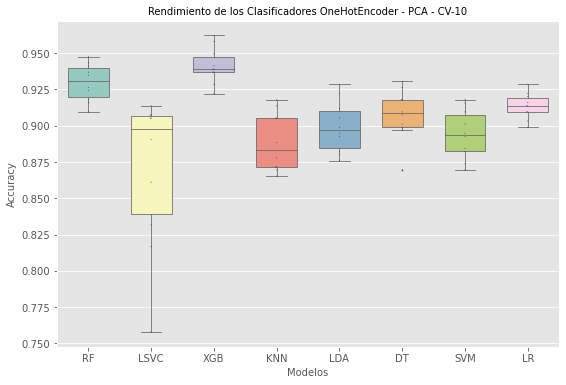

In [35]:
#sns.set_theme(style="whitegrid")
plt.figure(figsize=(9,6))
plt.title('Rendimiento de los Clasificadores OneHotEncoder - PCA - CV-10', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.xlabel('Modelos', fontsize=10)
ax = sns.boxplot(data=results, palette="Set3", linewidth=.75, width=.65, fliersize=1)
ax = sns.swarmplot(data=results, color=".25", size=0.75, edgecolor='blue', linewidth=0.1)
ax.set_xticklabels(names)
plt.show()

### CONSTRUCCION Y EVALUACION DE RENDIMIENTO - MODELO XGB

In [43]:
model = xgboost.XGBClassifier(num_class=3, learning_rate=0.01, max_depth=20, eval_metric='mlogloss')
model.fit(train_features, train_target)

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='mlogloss', gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.01, max_delta_step=0,
              max_depth=20, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=12,
              num_class=3, num_parallel_tree=1, objective='multi:softprob',
              predictor='auto', random_state=0, reg_alpha=0, reg_lambda=1,
              scale_pos_weight=None, subsample=1, tree_method='exact',
              validate_parameters=1, ...)

In [44]:
# save the model to disk
filename = '../MODELS/XGBModel_PCA_OrdinalEncoder-5937.sav'
print(filename)
pickle.dump(RF_model, open(filename, 'wb'))

../DATA/VF/XGBModel_PCA_OrdinalEncoder-5937.sav


In [45]:
predictionsXGB = model.predict(test_features)
print(accuracy_score(test_target, predictionsXGB))
print(precision_score(test_target, predictionsXGB, average=None))
print(confusion_matrix(test_target, predictionsXGB))
print(classification_report(test_target, predictionsXGB))

0.9444444444444444
[0.86764706 0.         0.95528069]
[[ 118    1   47]
 [   3    0    0]
 [  15    0 1004]]
              precision    recall  f1-score   support

           0       0.87      0.71      0.78       166
           1       0.00      0.00      0.00         3
           2       0.96      0.99      0.97      1019

    accuracy                           0.94      1188
   macro avg       0.61      0.57      0.58      1188
weighted avg       0.94      0.94      0.94      1188



Text(0.5, 0, 'Relative Importance')

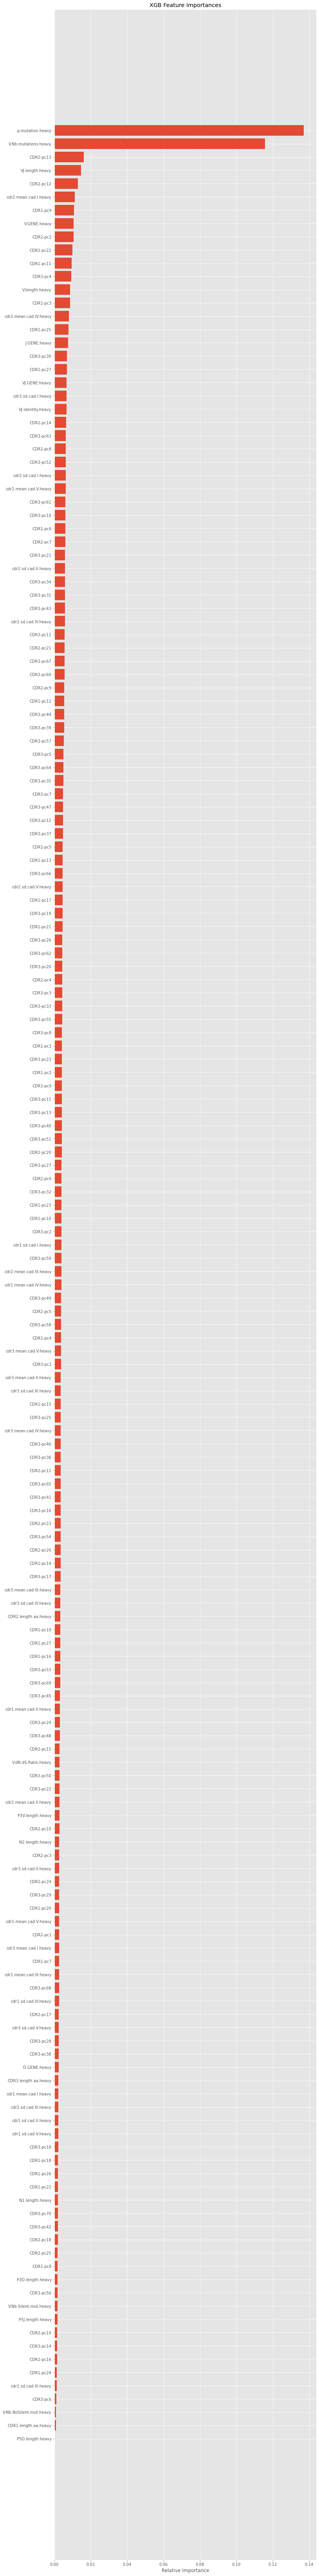

In [46]:
sorted_idx = model.feature_importances_.argsort()
plt.barh(train_features.columns[sorted_idx], model.feature_importances_[sorted_idx])
plt.gcf().set_size_inches(12, 120)
plt.title('XGB Feature Importances')
plt.xlabel("Relative Importance")

### CONSTRUCCION Y EVALUACION DE RENDIMIENTO - MODELO RF

In [47]:
RF_model = RandomForestClassifier(n_estimators=13)
RF_model.fit(train_features, train_target)
print(RF_model.score(train_features, train_target))

# save the model to disk
filename = '../MODELS/RFModel_PCA_OrdinalEncoder-5937.sav'
print(filename)
pickle.dump(RF_model, open(filename, 'wb'))


predictionsRF = RF_model.predict(test_features)
print(accuracy_score(test_target, predictionsRF))
print(precision_score(test_target, predictionsRF, average=None))
print(confusion_matrix(test_target, predictionsRF))
print(classification_report(test_target, predictionsRF))

0.9968414403032217
../DATA/VF/RFModel_PCA_OrdinalEncoder-5937.sav
0.9292929292929293
[0.86607143 0.         0.93674419]
[[  97    1   68]
 [   3    0    0]
 [  12    0 1007]]
              precision    recall  f1-score   support

           0       0.87      0.58      0.70       166
           1       0.00      0.00      0.00         3
           2       0.94      0.99      0.96      1019

    accuracy                           0.93      1188
   macro avg       0.60      0.52      0.55      1188
weighted avg       0.92      0.93      0.92      1188



[0.02239605 0.00533792 0.00164265 0.0104229  0.00405303 0.0068181
 0.00406622 0.00100481 0.00024446 0.0011079  0.00158781 0.05255352
 0.08055542 0.08230051 0.03541417 0.05278008 0.01217642 0.00241868
 0.00345437 0.00237301 0.00455263 0.00415286 0.00460238 0.00260422
 0.00269903 0.00221147 0.00309962 0.0065144  0.0063311  0.00213715
 0.00516194 0.00493953 0.01455891 0.00616736 0.00635925 0.00245439
 0.00499093 0.00323784 0.00386118 0.00424369 0.00537488 0.0018189
 0.00210159 0.00460904 0.00182897 0.00436132 0.00290869 0.00906781
 0.00262854 0.00402389 0.01438257 0.00353436 0.00359925 0.00473163
 0.00288943 0.00690602 0.00337909 0.00299489 0.00648192 0.01199363
 0.00290478 0.00215996 0.00267368 0.00343409 0.0050117  0.00105271
 0.00555262 0.00528815 0.00290409 0.00281495 0.00172809 0.00222639
 0.00189037 0.00241992 0.00226826 0.00662245 0.00221114 0.00482521
 0.00461214 0.00272555 0.00989634 0.00369734 0.00890016 0.00143792
 0.00535502 0.00223025 0.00411123 0.00367235 0.00621595 0.004108

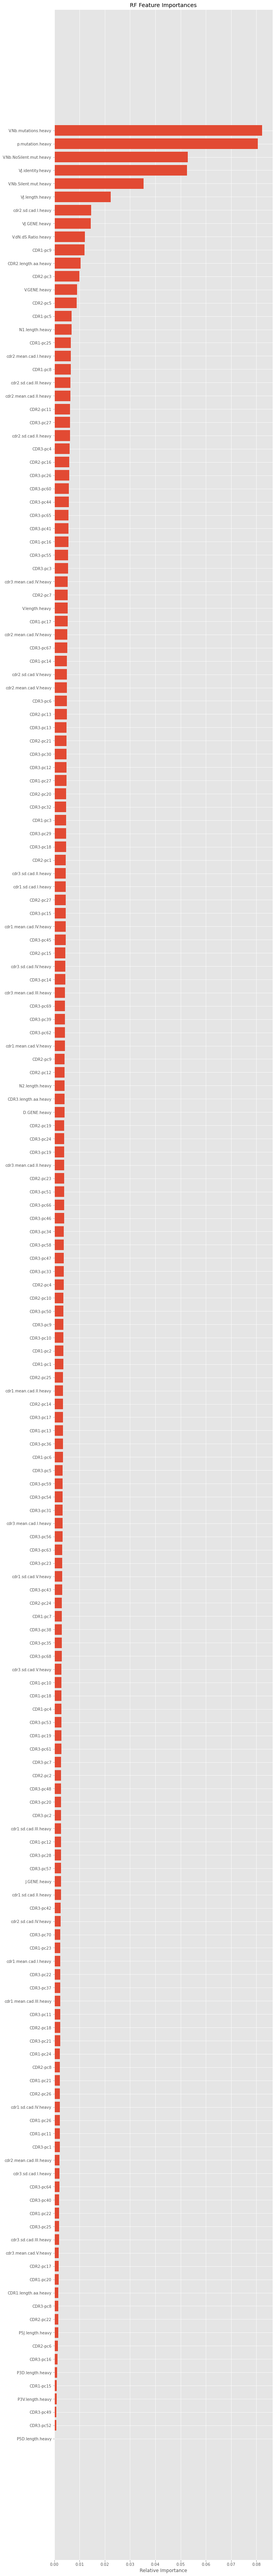

In [48]:
print(RF_model.feature_importances_)

importances = RF_model.feature_importances_
indices = np.argsort(importances)
features = train_features.columns
plt.figure(figsize=(10,120))
plt.title('RF Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### INTERPRETABILIDAD DEL MODELO RF

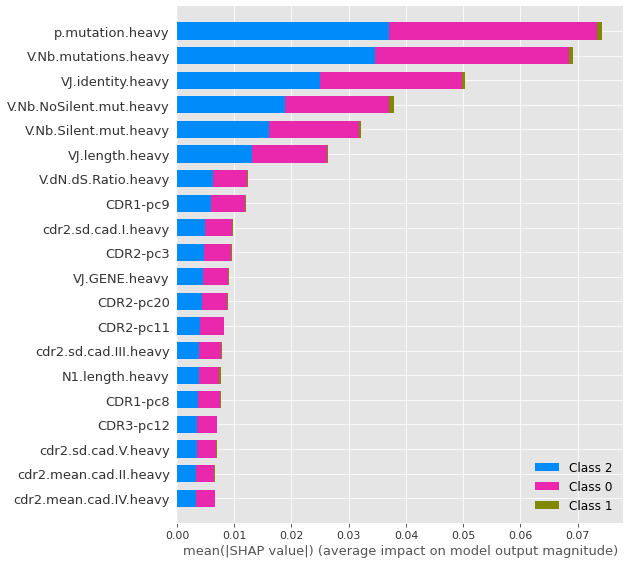

In [49]:
shap_values_train = shap.TreeExplainer(RF_model).shap_values(train_features)
shap.summary_plot(shap_values_train, train_features, plot_type='bar')

### INTERPRETABILIDAD DEL MODELO XGB

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


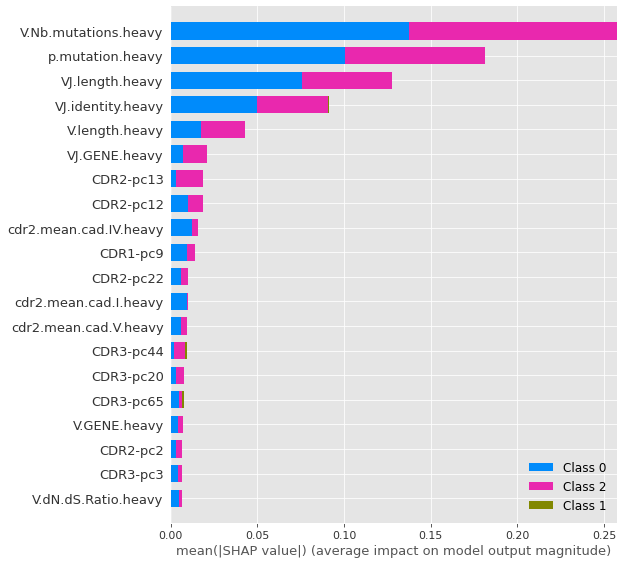

In [50]:
shap_values_train_XGB = shap.TreeExplainer(model).shap_values(train_features)
shap.summary_plot(shap_values_train_XGB, train_features, plot_type='bar')